## Visualización, evaluación y selección de características

Ahora que tenemos una idea general del dataset vamos a comenzar a realizar una exploración más profunda.

In [8]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_loader import load_lazy, load_columns
from src.config import CIC_TRAIN_PATH, CIC_TEST_PATH

In [9]:
train_df = load_lazy(CIC_TRAIN_PATH)

### Features continuas
Comenzamos analizando las características más númericas que vimos durante la exploración inicial. Teníamos la sospecha de que, al ser haber sido derivadas, podrían ser redundantes.

Vamos a comprobarlo mediante una matriz de correlación.

In [10]:
# Matriz de correlación
features = ["Header_Length", "Time_To_Live", "Rate", "Tot sum", "Min", "Max", "AVG", "Std", "Tot size", "IAT", "Number", "Variance"]
corr_matrix = train_df.select(features).collect().corr()

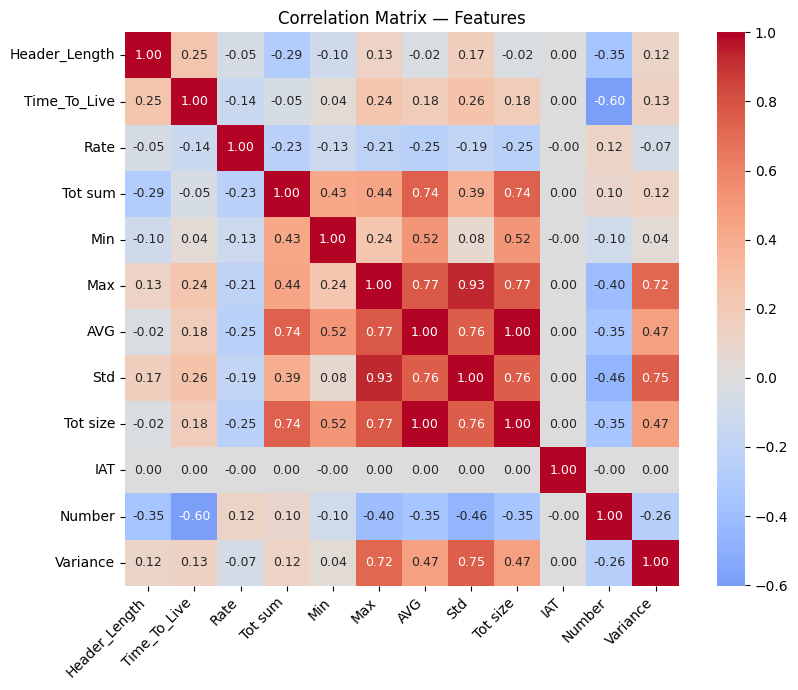

In [ ]:

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix.to_pandas(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, xticklabels=features, yticklabels=features, 
            annot_kws={"size": 9})
plt.title("Correlation Matrix — Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Efectivamente, podemos ver un cluster de features altamente correlacionadas.
* En primer lugar, "AVG" y "Tot size" tienen una correlación perfecta de 1, asi que podríamos quedarnos con solo una de las dos.
* En segundo lugar, observamos que el grupo de "Tot sum", "Min", "Max", "AVG", "Std", "Tot size" forma un cluster de correlaciones bastante altas.
    * Probablemente podamos quedarnos con 2 features. En este caso "AVG" y "Std" porque deberían ser las más representativas.
    * Como también observamos que "Std" está altamemente correlacionada con "Variance", también la podemos eliminar.

### Features de protocolos

Ahora vamos a investigar las features relacionadas con los protocolos ya que sospechábamos que podrían estar muy relacionadas.

Esta vez, en vez de una correlación directa, vamos a calcular las medias de cada columna respecto a cada valor de la columna "Protocol Type".
* Sabemos que estas columnas tienen valores entre 0 y 1.
    * Entonces, si la media es 1, significa que el valor de esa feature siempre está a 1 para un valor de "Protocol Type". Según lo que hemos visto en la exploración inicial, es probable, por ejemplo, que para "Protocol Type=6" la media de la columna "TCP" sea 1.

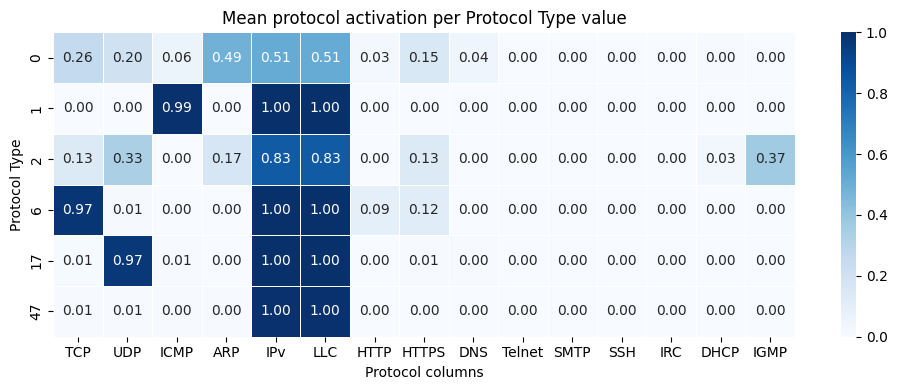

In [17]:
protocol_cols = ["TCP", "UDP", "ICMP", "ARP", "IPv", "LLC", "HTTP", "HTTPS", 
                 "DNS", "Telnet", "SMTP", "SSH", "IRC", "DHCP", "IGMP"]

result = (train_df.select(["Protocol Type"] + protocol_cols).collect().group_by("Protocol Type")
    .agg([pl.mean(c) for c in protocol_cols])
    .sort("Protocol Type")
)

pdf = result.to_pandas().set_index("Protocol Type")

plt.figure(figsize=(10, 4))
sns.heatmap(
    pdf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mean protocol activation per Protocol Type value")
plt.xlabel("Protocol columns")
plt.ylabel("Protocol Type")
plt.tight_layout()
plt.show()

"Tal y como sospechábamos, los resultados confirman la redundancia entre Protocol Type y varias columnas de protocolo. 

* IPv y LLC son prácticamente constantes en todos los grupos menos para Protocol Type = 0 y 2. 
* TCP, UDP e ICMP están casi perfectamente determinadas por Protocol Type (0.97-0.99), por lo que también son redundantes. 
* Las columnas de capa de aplicación (HTTP, HTTPS, DNS, SSH, etc.) en cambio son independientes y mantienen información propia. 

En conclusión, podemos eliminar TCP, UDP, ICMP, IPv y LLC.

### Features de flags

Finalmente, vamos con las features que dan información de los flags.

Por el nombre podemos intuir que son los paquetes que tienen esos flags activados y sus conteos (uno es una proporción de todos los paquetes de la conexión y otro los totales). Por lo que es probable que las columnas con el mismo nombre de flasg estén correlacionadas.

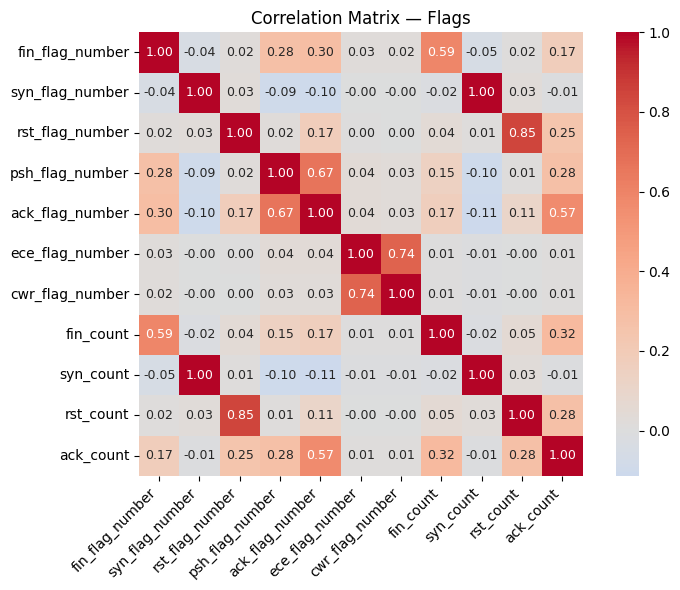

In [19]:
flag_features = ["fin_flag_number", "syn_flag_number", "rst_flag_number", "psh_flag_number", "ack_flag_number", "ece_flag_number", 
                 "cwr_flag_number", "fin_count", "syn_count", "rst_count", "ack_count"]

corr_matrix_flags = (train_df.select(flag_features).collect().corr())

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_flags.to_pandas(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=flag_features,
    yticklabels=flag_features,
    annot_kws={"size": 9},
)
plt.title("Correlation Matrix — Flags")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

En la matriz de correlación de los flags observamos lo siguiente: 
* Cada "flag_number" está altamente correlacionado con su "count" correspondiente ("syn_flag_number" ↔ "syn_count" = 1.00, "rst_flag_number" ↔ "rst_count" = 0.85, "fin_flag_number" ↔ "fin_count" = 0.59, "ack_flag_number" ↔ "ack_count" = 0.57), lo que confirma que los "count" son simplemente la versión absoluta de los "flag_number". 
* Segundo, dentro de los "flag_number" observamos algunas correlaciones moderadas: "psh_flag_number" ↔ "ack_flag_number" = 0.67 y "ece_flag_number" ↔ "cwr_flag_number" = 0.74, aunque no son lo suficientemente altas como para eliminar ninguna de ellas. 

Nos quedamos por tanto con los 7 "flag_number" y eliminamos los 4 "count".

### Features eliminadas

En resumen, las columnas que eliminamos son: "Tot sum", "Min", "Max", "Tot size", "Variance", "IPv", "LLC", "TCP", "UDP", "ICMP", "fin_count", "syn_count", "rst_count" y "ack_count".